In [1]:
import os
import zipfile
import random
import tensorflow as tf
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from shutil import copyfile

In [4]:
# If the URL doesn't work, visit https://www.microsoft.com/en-us/download/confirmation.aspx?id=54765
# And right click on the 'Download Manually' link to get a new URL to the dataset

# Note: This is a very large dataset and will take time to download

!wget --no-check-certificate \
"https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip" \
-O "/tmp/cats-and-dogs.zip" # Corrected -0 to -O

local_zip = '/tmp/cats-and-dogs.zip'
zip_ref = zipfile.ZipFile(local_zip, 'r')
zip_ref.extractall('/tmp')
zip_ref.close()

--2026-05-21 21:23:49--  https://download.microsoft.com/download/3/e/1/3e1c3f21-ecdb-4869-8368-6deba77b919f/kagglecatsanddogs_5340.zip
Resolving download.microsoft.com (download.microsoft.com)... 184.24.84.233, 2600:1417:8400:ab2::317f, 2600:1417:8400:a97::317f
Connecting to download.microsoft.com (download.microsoft.com)|184.24.84.233|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 824887076 (787M) [application/octet-stream]
Saving to: ‘/tmp/cats-and-dogs.zip’

/tmp/cats-and-dogs. 100%[===================>] 786.67M   113MB/s    in 7.9s    

2026-05-21 21:23:57 (99.8 MB/s) - ‘/tmp/cats-and-dogs.zip’ saved [824887076/824887076]



In [7]:
print(len(os.listdir('/tmp/PetImages/Cat/')))
print(len(os.listdir('/tmp/PetImages/Dog/')))

# Expected Output
# 12501
# 12501

12501
12501


In [8]:
try:
  os.mkdir('/tmp/cats-v-dogs')
  os.mkdir('/tmp/cats-v-dogs/training')
  os.mkdir('/tmp/cats-v-dogs/testing')
  os.mkdir('/tmp/cats-v-dogs/training/cats')
  os.mkdir('/tmp/cats-v-dogs/training/dogs')
  os.mkdir('/tmp/cats-v-dogs/testing/cats')
  os.mkdir('/tmp/cats-v-dogs/testing/dogs')
except OSError:
  pass

In [10]:
def split_data(SOURCE, TRAINING, TESTING, SPLIT_SIZE):
  files = []
  for filename in os.listdir(SOURCE):
    file = SOURCE + filename
    if os.path.getsize(file) > 0:
      files.append(filename)
    else:
      print(filename + " is zero length, so ignoring.")

  training_length = int(len(files) * SPLIT_SIZE)
  testing_length = int(len(files) - training_length)
  shuffled_set = random.sample(files, len(files))
  training_set = shuffled_set[0:training_length]
  testing_set = shuffled_set[-testing_length:]

  for filename in training_set:
    this_file = SOURCE + filename
    destination = TRAINING + filename
    copyfile(this_file, destination)

  for filename in testing_set:
    this_file = SOURCE + filename
    destination = TESTING + filename
    copyfile(this_file, destination)

CAT_SOURCE_DIR = "/tmp/PetImages/Cat/"
TRAINING_CATS_DIR = "/tmp/cats-v-dogs/training/cats/"
TESTING_CATS_DIR = "/tmp/cats-v-dogs/testing/cats/"
DOG_SOURCE_DIR = "/tmp/PetImages/Dog/"
TRAINING_DOGS_DIR = "/tmp/cats-v-dogs/training/dogs/"
TESTING_DOGS_DIR = "/tmp/cats-v-dogs/testing/dogs/" # Corrected from TESTING_CATS_DIR

split_size = .9
split_data(CAT_SOURCE_DIR, TRAINING_CATS_DIR, TESTING_CATS_DIR, split_size)
split_data(DOG_SOURCE_DIR, TRAINING_DOGS_DIR, TESTING_DOGS_DIR, split_size)

666.jpg is zero length, so ignoring.
11702.jpg is zero length, so ignoring.


In [11]:
print(len(os.listdir('/tmp/cats-v-dogs/training/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/training/dogs/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/cats/')))
print(len(os.listdir('/tmp/cats-v-dogs/testing/dogs/')))

# Expected output
# 11250
# 11250
# 1250
# 1250

12380
11250
1250
2379


In [12]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer=RMSprop(learning_rate=0.001), loss='binary_crossentropy', metrics=['acc'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
TRAINING_DIR = "/tmp/cats-v-dogs/training/"
train_datagen = ImageDataGenerator(rescale=1.0/255.)
train_generator = train_datagen.flow_from_directory(TRAINING_DIR,
                                                    batch_size=250,
                                                    class_mode='binary',
                                                    target_size=(150, 150))
VALIDATION_DIR = "/tmp/cats-v-dogs/testing/"
validation_datagen = ImageDataGenerator(rescale=1.0/255.)
validation_generator = validation_datagen.flow_from_directory(VALIDATION_DIR,
                                                              batch_size=250,
                                                              class_mode='binary',
                                                              target_size=(150, 150))

# Expected Output:
# Found 23629 images belonging to 2 classes.
# Found 3628 images belonging to 2 classes.

Found 23629 images belonging to 2 classes.
Found 3628 images belonging to 2 classes.


In [15]:
# Note that this may take some time.
history = model.fit(train_generator, epochs=15, steps_per_epoch=90, validation_data=validation_generator, validation_steps=6)

Epoch 1/15
39/90 ━━━━━━━━━━━━━━━━━━━━ 5:31 6s/step - acc: 0.5246 - loss: 1.1730

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


90/90 ━━━━━━━━━━━━━━━━━━━━ 581s 6s/step - acc: 0.5628 - loss: 0.7464 - val_acc: 0.4013 - val_loss: 0.7747
Epoch 2/15
 5/90 ━━━━━━━━━━━━━━━━━━━━ 8:37 6s/step - acc: 0.6154 - loss: 0.6512

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


90/90 ━━━━━━━━━━━━━━━━━━━━ 44s 422ms/step - acc: 0.5720 - loss: 0.6771 - val_acc: 0.5087 - val_loss: 0.7011
Epoch 3/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 622s 7s/step - acc: 0.6751 - loss: 0.6126 - val_acc: 0.5720 - val_loss: 0.7045
Epoch 4/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 421ms/step - acc: 0.7088 - loss: 0.5466 - val_acc: 0.6200 - val_loss: 0.6506
Epoch 5/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 589s 7s/step - acc: 0.7090 - loss: 0.5657 - val_acc: 0.5740 - val_loss: 0.7242
Epoch 6/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 49s 491ms/step - acc: 0.7752 - loss: 0.5149 - val_acc: 0.5607 - val_loss: 0.7652
Epoch 7/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 637s 7s/step - acc: 0.7442 - loss: 0.5105 - val_acc: 0.6587 - val_loss: 0.6434
Epoch 8/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 82s 843ms/step - acc: 0.7440 - loss: 0.5286 - val_acc: 0.6067 - val_loss: 0.7495
Epoch 9/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 561s 6s/step - acc: 0.7747 - loss: 0.4722 - val_acc: 0.6473 - val_loss: 0.6608
Epoch 10/15
90/90 ━━━━━━━━━━━━━━━━━━━━ 43s 407ms/step - acc: 0.8224

<Figure size 640x480 with 0 Axes>

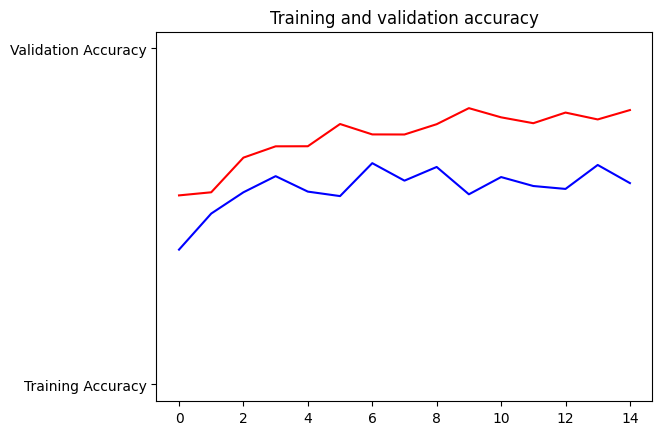

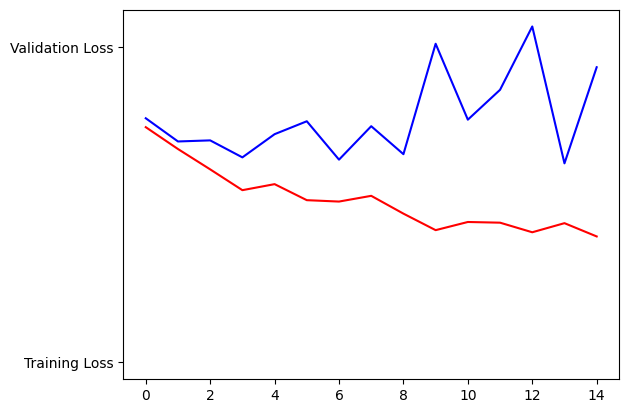

<Figure size 640x480 with 0 Axes>

In [16]:
%matplotlib inline

import matplotlib.image  as mpimg
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Retrieve a list of list results on training and test data
# sets for each training epoch
# ----------------------------------------------------------
acc=history.history['acc']
val_acc=history.history['val_acc']
loss=history.history['loss']
val_loss=history.history['val_loss']

epochs=range(len(acc)) # Get number of epochs

# ----------------------------------------------------------
# Plot training and validation accuracy per epoch
# ----------------------------------------------------------
plt.plot(epochs, acc, 'r', "Training Accuracy")
plt.plot(epochs, val_acc, 'b', "Validation Accuracy")
plt.title('Training and validation accuracy')
plt.figure()

# ----------------------------------------------------------
# Plot training and validation loss per epoch
# ----------------------------------------------------------
plt.plot(epochs, loss, 'r', "Training Loss")
plt.plot(epochs, val_loss, 'b', "Validation Loss")
plt.figure()

# Desired output. Charts with training and validation metrics. No crash :)